# Setup Environment

In [1]:
# Install necessary libraries using magic command
%pip install --break-system-packages -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import necessary libraries

# pyright: reportMissingImports=false

# Standard libraries
import os
import sys
import gc
import random
import json
from pathlib import Path

# Suppress TensorFlow warnings and logs
sys.stderr.flush()
devnull = os.open(os.devnull, os.O_WRONLY)
os.dup2(devnull, 2)
os.close(devnull)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'

# Machine learning libraries
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models, mixed_precision
from tensorflow.keras.utils import load_img
mixed_precision.set_global_policy('mixed_float16')

# Evaluation libraries
from sklearn.metrics import classification_report, confusion_matrix

# Data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Other libraries
from tqdm.keras import TqdmCallback

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 5070, compute capability 12.0


In [3]:
# Set GPU configuration to allow memory growth

# GPU Configuration
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
        
# Check TensorFlow version and GPU availability
print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available:", len(gpus))
print("GPU Name:", gpus)

TensorFlow Version: 2.17.0
Num GPUs Available: 1
GPU Name: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Set random seeds for reproducibility

# os.environ['TF_DETERMINISTIC_OPS'] = '1'    # Ensure deterministic operations in TensorFlow

# Define the seed for various libraries to ensure reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Random seed set to: {SEED}")

Random seed set to: 42


In [5]:
# Create dictory for plots and models

plots_dir      = Path('./plots')
eda_plots_dir  = plots_dir / 'eda'
eval_plots_dir = plots_dir / 'evaluation'

results_dir = Path('./results')
models_dir  = Path('./models')

plots_dir.mkdir(parents=True, exist_ok=True)
eda_plots_dir.mkdir(parents=True, exist_ok=True)
eval_plots_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

# Data Collection

In [6]:
# Load the Stanford Dogs dataset using TensorFlow Datasets (TFDS)

# 80% Train, 20% Val from the original train split, plus untouched Test
(ds_train, ds_val, ds_test), ds_info = tfds.load(
    'stanford_dogs',
    split=['train[:80%]', 'train[80%:]', 'test'],
    as_supervised=True,
    with_info=True,
    data_dir='./data',
    try_gcs=True        # Use Google Cloud Storage if available for faster download
)

print(f"Train samples: {len(ds_train)}")  # 9,600 images
print(f"Val samples:   {len(ds_val)}")    # 2,400 images
print(f"Test samples:  {len(ds_test)}")   # 8,580 images

Train samples: 9600
Val samples:   2400
Test samples:  8580


# Exploratory Data Analysis

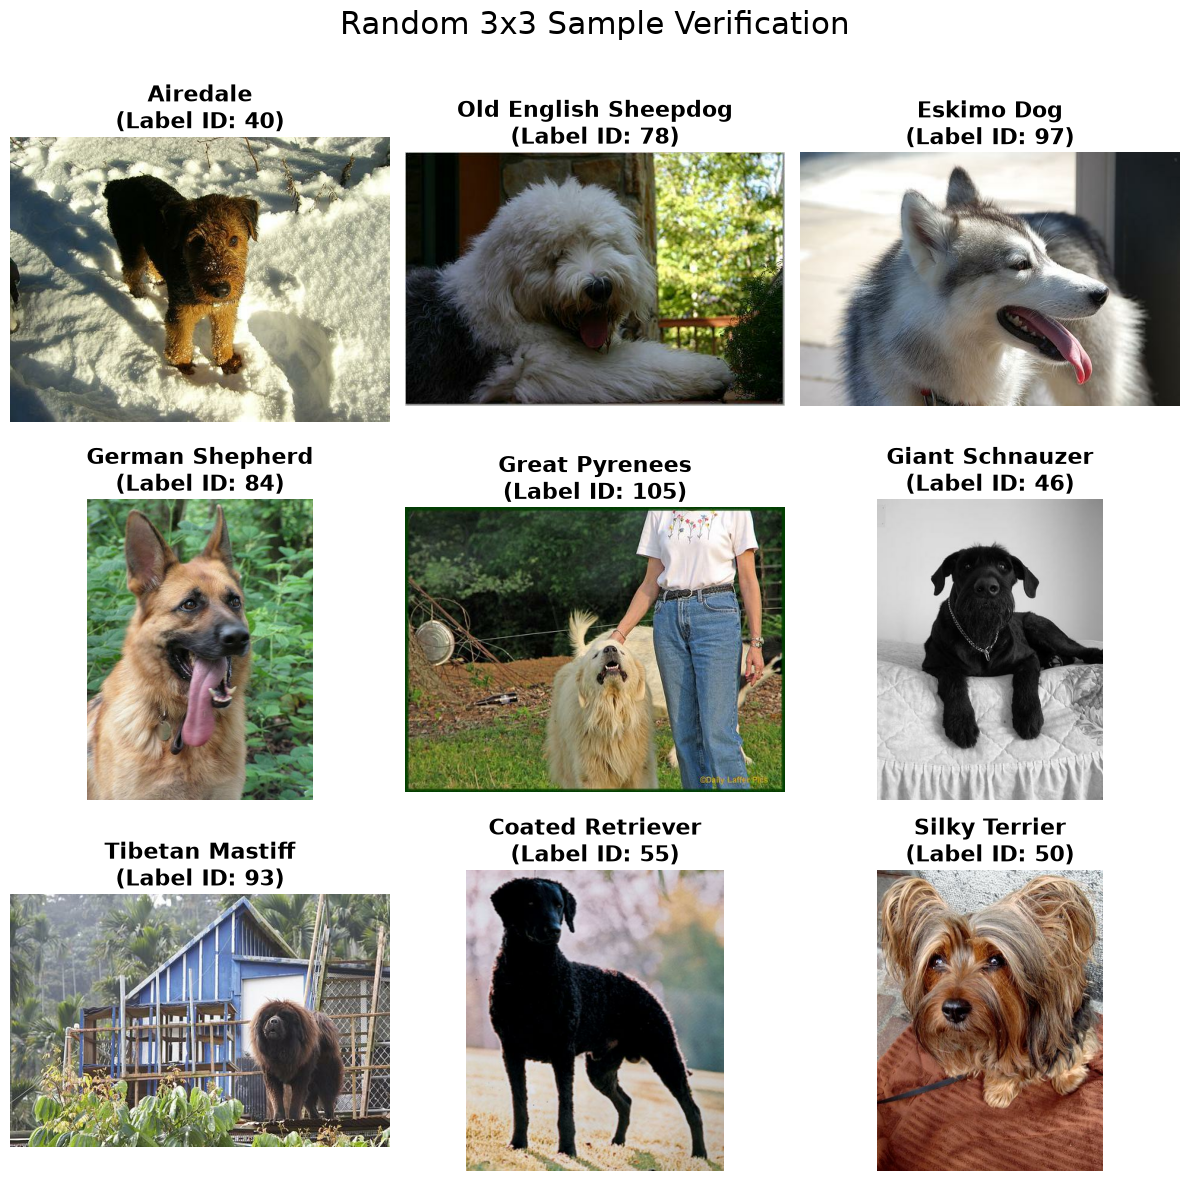

In [7]:
# 1. Visualize a random 3x3 sample of images from the training dataset

# Extract class names and clean them for better readability
# Name example: 'n02085620-Chihuahua' -> 'Chihuahua'
raw_names = ds_info.features['label'].names
clean_names = [name.split('-')[-1].replace('_', ' ').title() for name in raw_names]


plt.figure(figsize=(12, 12))

for i, (image, label) in enumerate(ds_train.shuffle(buffer_size=1000, seed=42).take(9)):
    ax = plt.subplot(3, 3, i + 1)
    
    # Convert the image tensor to a NumPy array and display it
    plt.imshow(image.numpy().astype("uint8"))
    
    # Get the corresponding breed name
    label_idx = label.numpy()
    breed_name = clean_names[label_idx]
    
    plt.title(f"{breed_name}\n(Label ID: {label_idx})", fontsize=16, fontweight='bold')
    plt.axis("off")

plt.suptitle("Random 3x3 Sample Verification", fontsize=22, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(eda_plots_dir / '01_random_sample_verification.png', dpi=300)
plt.show()

Min images per breed: 70
Max images per breed: 163
Mean images per breed: 80.67


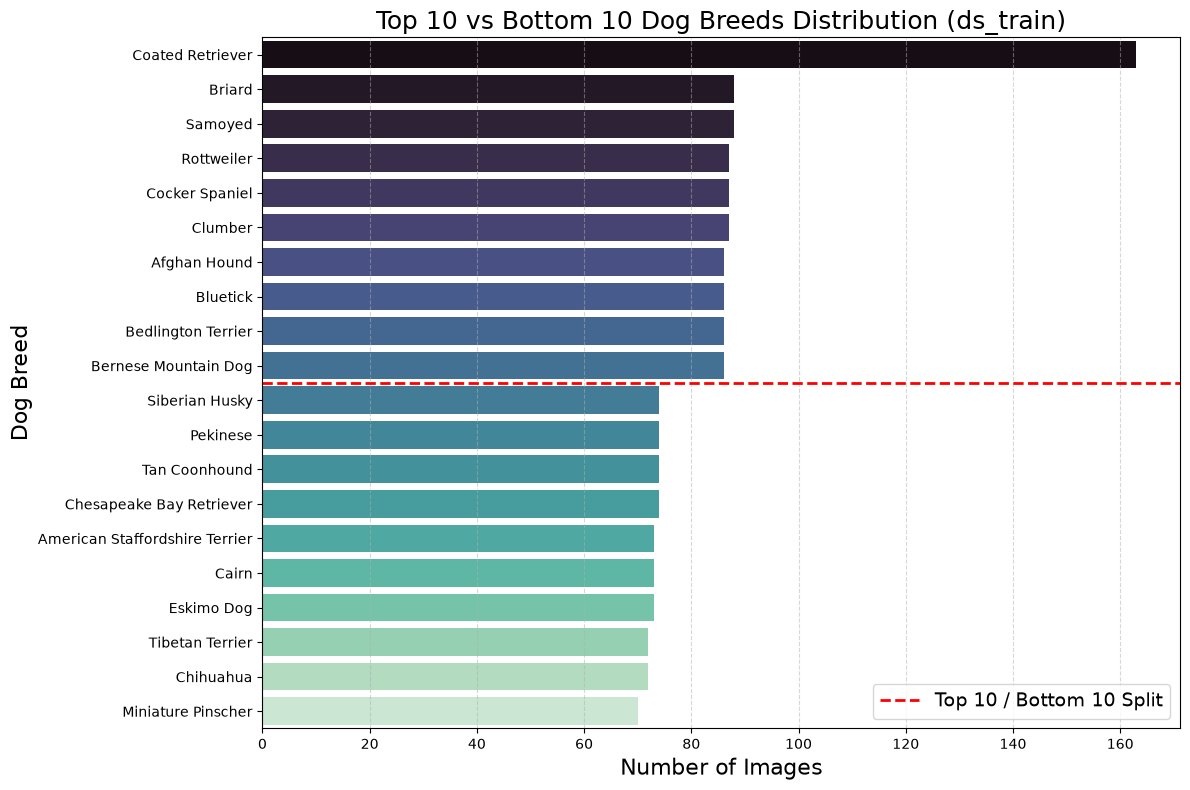

In [8]:
# 2. Class Distribution Bar Chart

# Create a dataset of labels only from the training dataset
labels_ds = ds_train.map(lambda img, label: label)

# Extract all labels from the dataset
train_labels = []
for label_batch in labels_ds.batch(1024):
    train_labels.extend(label_batch.numpy())

# Create a DataFrame to count the occurrences of each breed
df_classes = pd.DataFrame({'Breed': [clean_names[i] for i in train_labels]})
class_counts = df_classes['Breed'].value_counts().reset_index()
class_counts.columns = ['Breed', 'Count']


# Print the min max and mean of the class counts
print(f"Min images per breed: {class_counts['Count'].min()}")
print(f"Max images per breed: {class_counts['Count'].max()}")
print(f"Mean images per breed: {class_counts['Count'].mean():.2f}")


# plot the top 10 and bottom 10 dog breeds based on the number of images in the training dataset
plt.figure(figsize=(12, 8))
top_bottom = pd.concat([class_counts.head(10), class_counts.tail(10)])
sns.barplot(data=top_bottom, y='Breed', x='Count', hue='Breed', palette='mako', legend=False)

# Add a horizontal line to separate the top and bottom breeds
plt.axhline(y=9.5, color='red', linestyle='--', linewidth=2, label='Top 10 / Bottom 10 Split')

plt.title('Top 10 vs Bottom 10 Dog Breeds Distribution (ds_train)', fontsize=18)
plt.xlabel('Number of Images', fontsize=16)
plt.ylabel('Dog Breed', fontsize=16)
plt.legend(loc='lower right', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(eda_plots_dir / '02_breeds_distribution.png', dpi=300)
plt.show()

In [9]:
# Optional: Visualize the distribution of all 120 dog breeds

# plt.figure(figsize=(10, 24))
# sns.barplot(data=class_counts, y='Breed', x='Count', hue='Breed', palette='viridis', legend=False)
# plt.title('All 120 Dog Breeds Distribution', fontsize=14)
# plt.xlabel('Number of Images')
# plt.ylabel('Dog Breed')
# plt.grid(axis='x', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()

Min Dimension: 100 x 103
Max Dimension: 2740 x 2560
Mean Dimension: 444 x 388


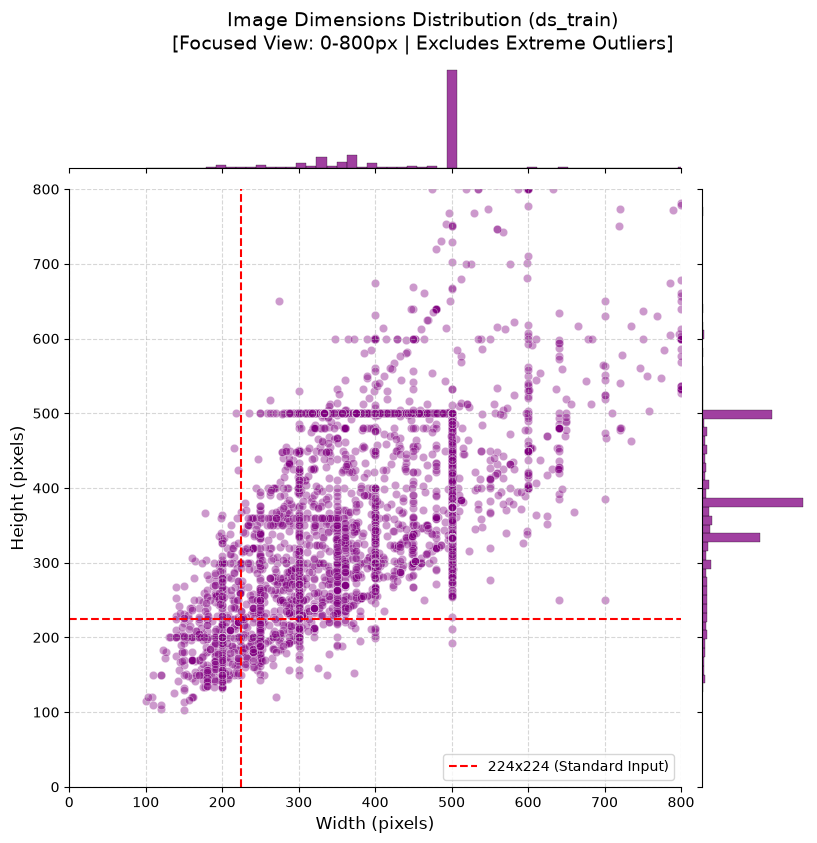

In [10]:
# 3. Image Dimension Scatter Plot

# Extract the width and height of all images in the training dataset
widths = []
heights = []
for img, _ in ds_train:
    shape = img.shape
    heights.append(shape[0])
    widths.append(shape[1])

# Print the min, max, and mean dimensions of the images
print(f"Min Dimension: {min(widths)} x {min(heights)}")
print(f"Max Dimension: {max(widths)} x {max(heights)}")
print(f"Mean Dimension: {int(np.mean(widths))} x {int(np.mean(heights))}")

# plot the scatter plot of image dimensions
g = sns.jointplot(
    x=widths, 
    y=heights, 
    kind='scatter', 
    alpha=0.4, 
    color='purple',
    height=8
)

# Mark common pre-trained model input sizes
g.ax_joint.axvline(224, color='red', linestyle='--', label='224x224 (Standard Input)')
g.ax_joint.axhline(224, color='red', linestyle='--')
g.ax_joint.legend()

# Set the x and y limits to focus on the majority of the data, excluding extreme outliers
g.ax_joint.set_xlim(0, 800)
g.ax_joint.set_ylim(0, 800)
g.set_axis_labels('Width (pixels)', 'Height (pixels)', fontsize=12)

# Set the title and adjust layout
g.fig.suptitle('Image Dimensions Distribution (ds_train)\n[Focused View: 0-800px | Excludes Extreme Outliers]', y=1.02, fontsize=14)
g.fig.subplots_adjust(top=0.95)

plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(eda_plots_dir / '03_image_dimensions_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# Stage 1 : Feature Extraction

In [11]:
# Define the Data Augmentation Layer (Prevent Overfitting)

data_augmentation = models.Sequential(
        [
            layers.RandomFlip("horizontal"),         # Random horizontal flip
            layers.RandomRotation(0.15),             # Random rotation ±15%
            layers.RandomZoom(0.15),                 # Random zoom in/out ±15%
            layers.RandomTranslation(0.1, 0.1),      # Random translation ±10%
        ], 
        name="data_augmentation"
    )

In [12]:
# Processing the datasets for EfficientNetV2B3
IMG_SIZE = 300
BATCH_SIZE = 32
BUFFER_SIZE = 1000

# Define a preprocessing function to resize images to the required input size for EfficientNetV2B3
def preprocess_img(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

# Process the Training Dataset (ds_train -> ds_train_proc)
ds_train_proc = ds_train.map(preprocess_img, num_parallel_calls=4)
ds_train_proc = ds_train_proc.shuffle(buffer_size=BUFFER_SIZE).batch(BATCH_SIZE).prefetch(2)

# Process the Validation Dataset (ds_val -> ds_val_proc)
ds_val_proc = ds_val.map(preprocess_img, num_parallel_calls=4)
ds_val_proc = ds_val_proc.batch(BATCH_SIZE).prefetch(2)

# Process the Test Dataset (ds_test -> ds_test_proc)
ds_test_proc = ds_test.map(preprocess_img, num_parallel_calls=4)
ds_test_proc = ds_test_proc.batch(BATCH_SIZE).prefetch(2)

In [13]:
# Load the pre-trained EfficientNetV2B3 model as the backbone for transfer learning
base_model = tf.keras.applications.EfficientNetV2B3(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
# Freeze the base model to prevent its weights from being updated during training
base_model.trainable = False

52606240/52606240 [==============================] - 5s 0us/step


In [18]:
# Model Building and Training

# Data Augmentation + Backbone + Head
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))    # (300, 300, 3), 3 channels for RGB images
x = data_augmentation(inputs)                           # Data Augmentation to prevent overfitting
x = base_model(x, training=False)                       # Keep BatchNormalization in inference mode
x = layers.GlobalAveragePooling2D()(x)                  # Global Average Pooling to reduce the spatial dimensions
x = layers.Dropout(0.3)(x)                              # Dropout 30% to prevent overfitting
outputs = layers.Dense(120, activation='softmax')(x)    # Prediction layer for 120 dog breeds

model = models.Model(inputs, outputs)

# Compile Model (Stage 1 : Larger Learning Rate)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Stage 1
print("Starting Stage 1 Training...")

history_stage1 = model.fit(
    ds_train_proc,
    validation_data=ds_val_proc,
    epochs=8
)

print("Stage 1 Training Complete!")

Starting Stage 1 Training...
Epoch 1/8
300/300 [==============================] - 32s 61ms/step - loss: 1.1913 - accuracy: 0.6873 - val_loss: 0.4770 - val_accuracy: 0.8421
Epoch 2/8
300/300 [==============================] - 16s 54ms/step - loss: 0.6714 - accuracy: 0.7957 - val_loss: 0.4212 - val_accuracy: 0.8600
Epoch 3/8
300/300 [==============================] - 17s 55ms/step - loss: 0.5375 - accuracy: 0.8355 - val_loss: 0.4027 - val_accuracy: 0.8750
Epoch 4/8
300/300 [==============================] - 17s 54ms/step - loss: 0.4567 - accuracy: 0.8564 - val_loss: 0.3680 - val_accuracy: 0.8817
Epoch 5/8
300/300 [==============================] - 16s 53ms/step - loss: 0.4169 - accuracy: 0.8668 - val_loss: 0.3997 - val_accuracy: 0.8687
Epoch 6/8
300/300 [==============================] - 16s 53ms/step - loss: 0.3596 - accuracy: 0.8844 - val_loss: 0.3939 - val_accuracy: 0.8796
Epoch 7/8
300/300 [==============================] - 16s 53ms/step - loss: 0.3145 - accuracy: 0.8971 - val_loss: 

# Stage 2: Fine Tuning

In [19]:
# Unfreeze the top 50 layers of the base model for fine-tuning

# Unfreeze the entire base model for fine-tuning
base_model.trainable = True

# Keep the first N layers frozen and only fine-tune the last 50 layers of the base model
fine_tune_at = len(base_model.layers) - 50
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Total layers in base model: {len(base_model.layers)}")
print(f"Layers frozen: {fine_tune_at}, Layers unfrozen for training: 50")

Total layers in base model: 409
Layers frozen: 359, Layers unfrozen for training: 50


In [20]:
# Stage 2: Fine-Tuning

gc.collect()
tf.keras.backend.clear_session()

# Compile the model again with smaller learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Much smaller Learning Rate
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping Callbacks, Prevent Overfitting
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,                   # Stops if no improvement in validation loss for 5 consecutive epochs
        restore_best_weights=True 
    )
]

# Stage 2 Fine-Tuning
initial_epochs = len(history_stage1.history['loss'])
fine_tune_epochs = 12
total_epochs = initial_epochs + fine_tune_epochs

print("Starting Stage 2 Fine-Tuning...")

history_stage2 = model.fit(
    ds_train_proc,
    validation_data=ds_val_proc,
    epochs=total_epochs,
    initial_epoch=history_stage1.epoch[-1] + 1,
    callbacks=callbacks
)

print("Stage 2 Fine-Tuning Complete!")

Starting Stage 2 Fine-Tuning...
Epoch 9/20
300/300 [==============================] - 33s 65ms/step - loss: 0.2292 - accuracy: 0.9320 - val_loss: 0.3486 - val_accuracy: 0.8888
Epoch 10/20
300/300 [==============================] - 17s 56ms/step - loss: 0.1824 - accuracy: 0.9414 - val_loss: 0.3352 - val_accuracy: 0.8913
Epoch 11/20
300/300 [==============================] - 17s 56ms/step - loss: 0.1506 - accuracy: 0.9538 - val_loss: 0.3291 - val_accuracy: 0.8992
Epoch 12/20
300/300 [==============================] - 17s 55ms/step - loss: 0.1354 - accuracy: 0.9565 - val_loss: 0.3278 - val_accuracy: 0.8988
Epoch 13/20
300/300 [==============================] - 17s 55ms/step - loss: 0.1389 - accuracy: 0.9569 - val_loss: 0.3269 - val_accuracy: 0.8975
Epoch 14/20
300/300 [==============================] - 17s 55ms/step - loss: 0.1219 - accuracy: 0.9599 - val_loss: 0.3298 - val_accuracy: 0.8979
Epoch 15/20
300/300 [==============================] - 17s 55ms/step - loss: 0.1160 - accuracy: 0.9

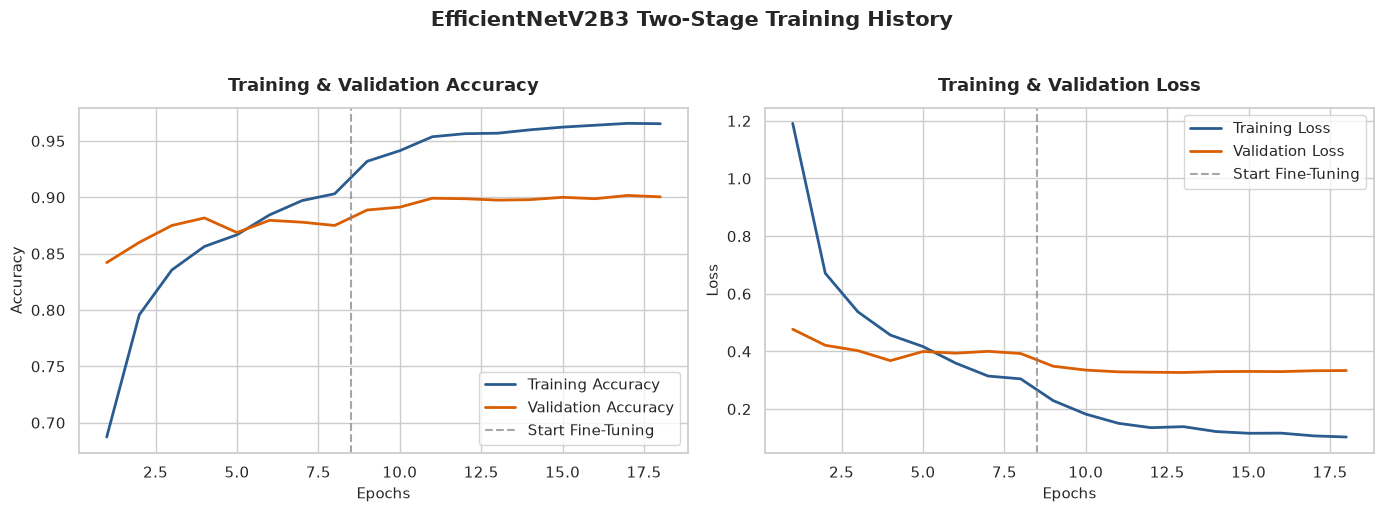

In [21]:
# Visualize the training history for both Stage 1 and Stage 2

sns.set_theme(style="whitegrid")

def plot_training_history(history1, history2):
    # Find the number of epochs in Stage 1
    stage1_end_epoch = len(history1.history['accuracy'])

    # Use + to avoid modifying the original data in history1
    acc = history1.history['accuracy'] + history2.history['accuracy']
    val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
    loss = history1.history['loss'] + history2.history['loss']
    val_loss = history1.history['val_loss'] + history2.history['val_loss']

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # --- Plot 1: Accuracy ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#2b5c8f', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#d95f02', linewidth=2)
    plt.axvline(x=stage1_end_epoch + 0.5, color='gray', linestyle='--', alpha=0.7, label='Start Fine-Tuning')
    
    plt.title('Training & Validation Accuracy', fontsize=13, fontweight='bold', pad=12)
    plt.xlabel('Epochs', fontsize=11)
    plt.ylabel('Accuracy', fontsize=11)
    plt.legend(loc='lower right', frameon=True, facecolor='white')

    # --- Plot 2: Loss ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#2b5c8f', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#d95f02', linewidth=2)
    plt.axvline(x=stage1_end_epoch + 0.5, color='gray', linestyle='--', alpha=0.7, label='Start Fine-Tuning')
    
    plt.title('Training & Validation Loss', fontsize=13, fontweight='bold', pad=12)
    plt.xlabel('Epochs', fontsize=11)
    plt.ylabel('Loss', fontsize=11)
    plt.legend(loc='upper right', frameon=True, facecolor='white')

    plt.suptitle('EfficientNetV2B3 Two-Stage Training History', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(eval_plots_dir / '01_training_history_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history_stage1, history_stage2)

# Evaluation on Test Set

In [22]:
# Make predictions on the test dataset and evaluate the model's performance

y_pred_probs = model.predict(ds_test_proc)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y for x, y in ds_test_proc], axis=0)

269/269 [==============================] - 9s 26ms/step


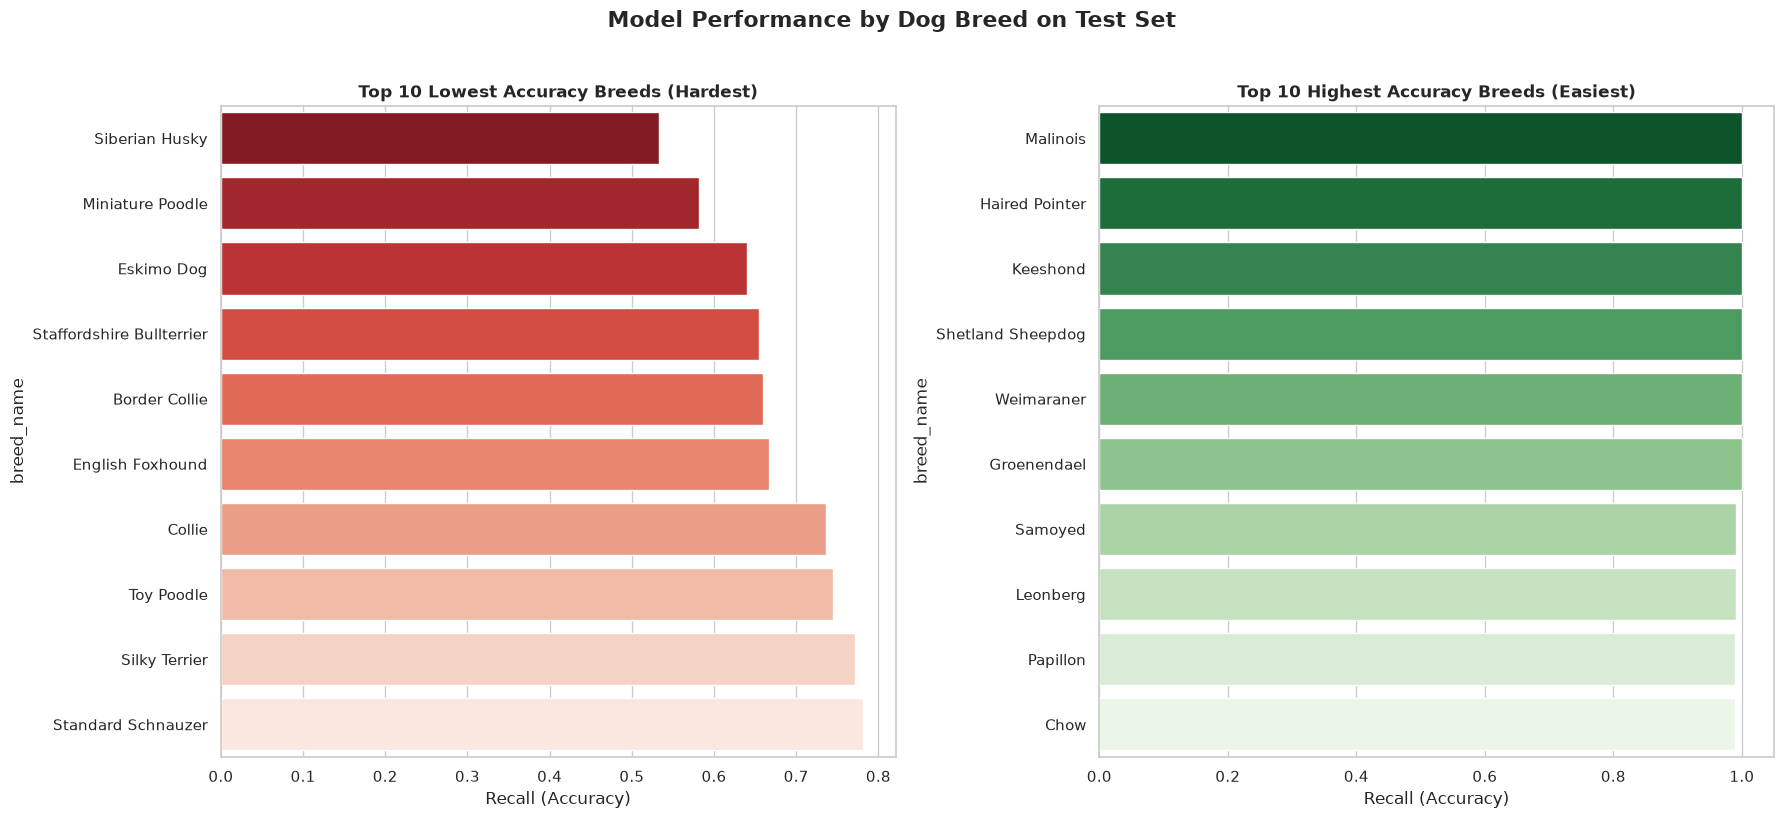

In [23]:
# Top 10 best / worst performing breeds

# Generate a classification report and convert it to a DataFrame for further analysis
report = classification_report(y_true, y_pred, target_names=clean_names, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report['breed_name'] = df_report.index
df_report.to_csv(results_dir / 'classification_report.csv', index=False)

# Sort the DataFrame by recall to find the top 10 lowest and highest accuracy breeds
lowest_acc  = df_report.sort_values(by='recall').head(10)
highest_acc = df_report.sort_values(by='recall', ascending=False).head(10)

# Plot the top 10 lowest and highest accuracy breeds side by side for comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 10 Lowest Accuracy Breeds (Hardest)
sns.barplot(data=lowest_acc, x='recall', y='breed_name', ax=axes[0], palette='Reds_r', hue='breed_name', legend=False)
axes[0].set_title('Top 10 Lowest Accuracy Breeds (Hardest)', fontweight='bold')
axes[0].set_xlabel('Recall (Accuracy)')

# Top 10 Highest Accuracy Breeds (Easiest)
sns.barplot(data=highest_acc, x='recall', y='breed_name', ax=axes[1], palette='Greens_r', hue='breed_name', legend=False)
axes[1].set_title('Top 10 Highest Accuracy Breeds (Easiest)', fontweight='bold')
axes[1].set_xlabel('Recall (Accuracy)')

plt.suptitle('Model Performance by Dog Breed on Test Set', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(eval_plots_dir / '02_top_bottom_breeds_performance.png', dpi=300, bbox_inches='tight')
plt.show()

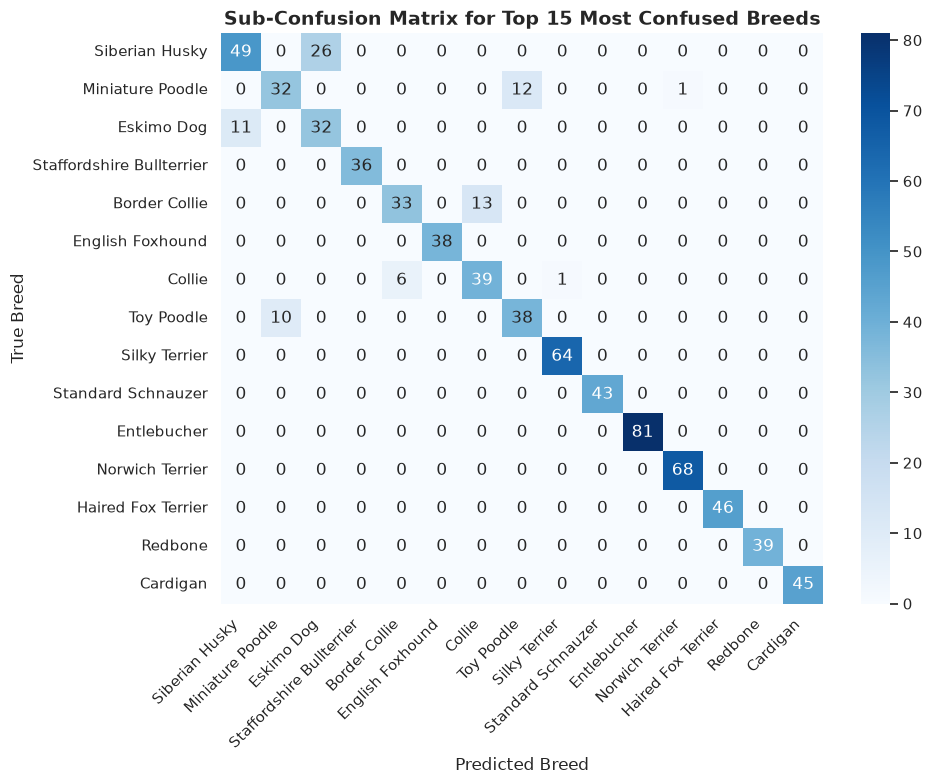

In [24]:
# Sub-Confusion Matrix

# Drop the accuracy, macro avg, weighted avg rows
df_classes_only = df_report.drop(index=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# Find the 15 breeds with the lowest recall (accuracy) for further analysis
lowest_recall_names = df_classes_only.sort_values(by='recall', ascending=True).head(15).index.tolist()

# Get the corresponding class indices for these breeds
top_error_classes = [clean_names.index(name) for name in lowest_recall_names]

# Filter the true and predicted labels to only include the top error classes
mask = np.isin(y_true, top_error_classes) & np.isin(y_pred, top_error_classes)
sub_cm = confusion_matrix(y_true[mask], y_pred[mask], labels=top_error_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(sub_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=lowest_recall_names, 
            yticklabels=lowest_recall_names)

plt.title('Sub-Confusion Matrix for Top 15 Most Confused Breeds', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Breed')
plt.ylabel('True Breed')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(eval_plots_dir / '03_sub_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

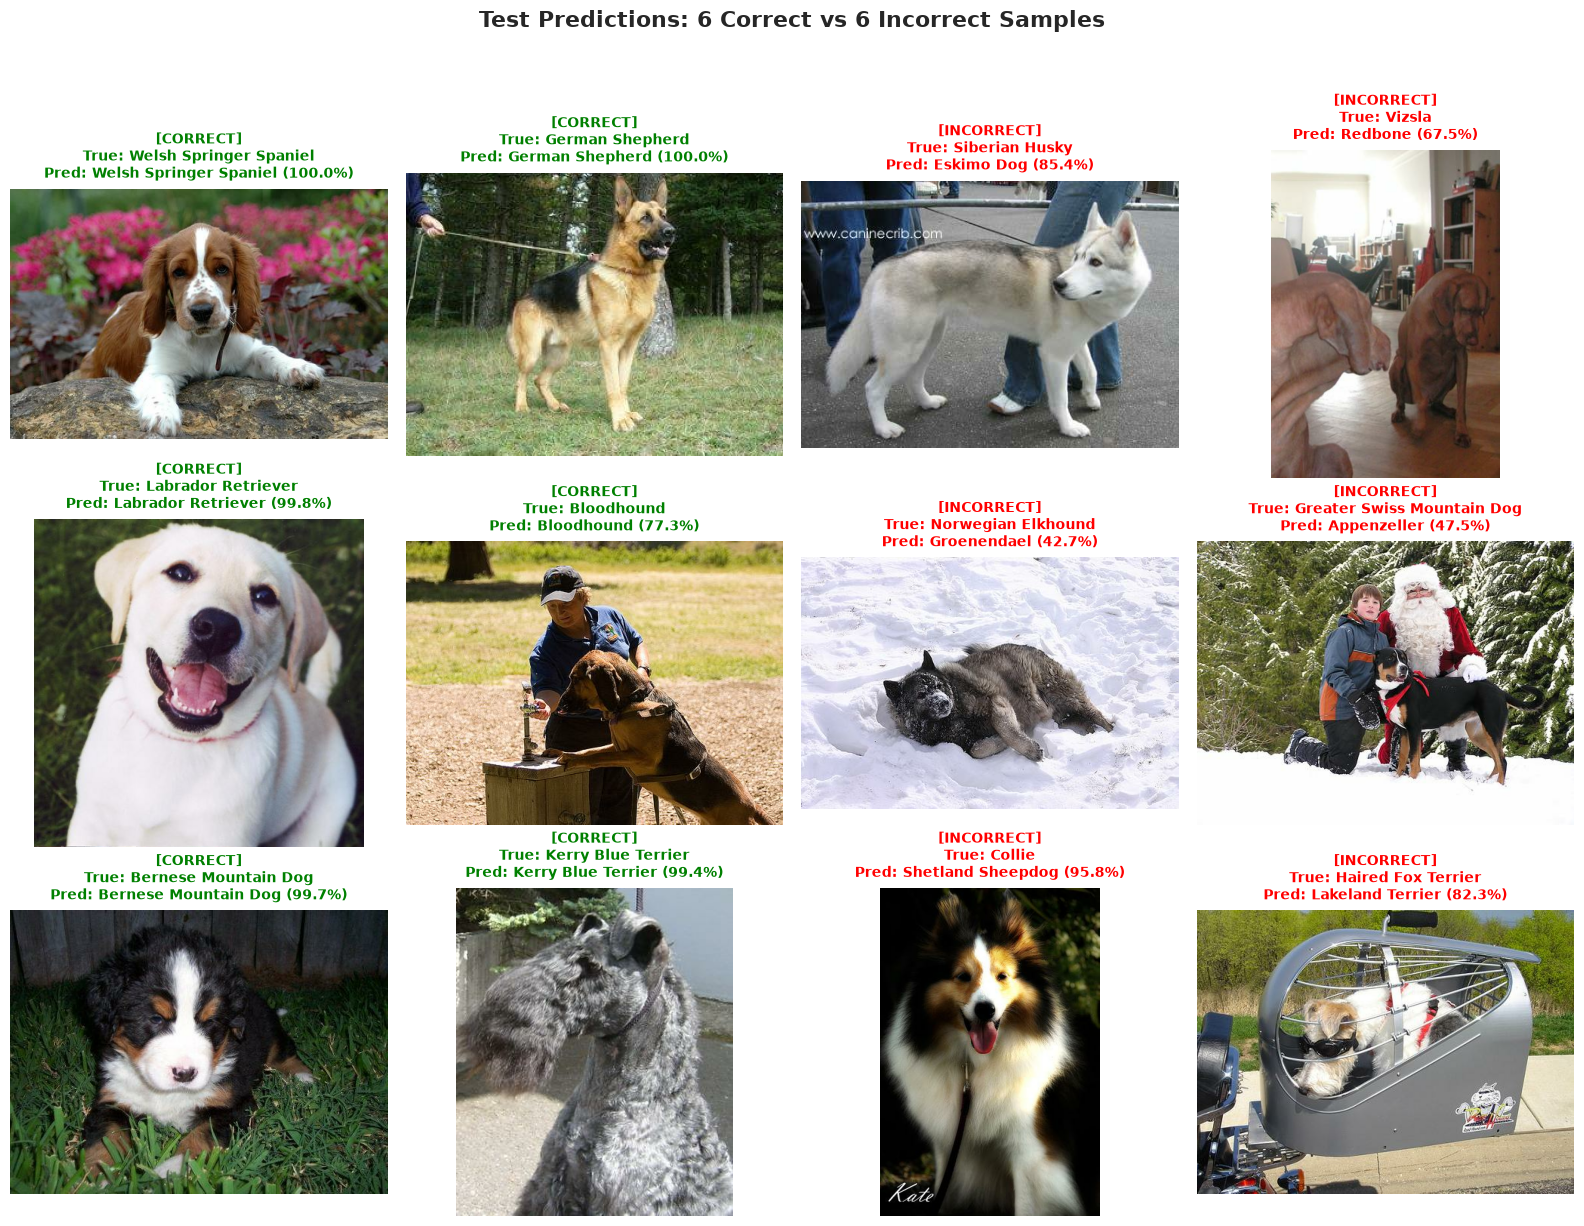

In [25]:
# Visual Inspection of Predictions

correct_samples = []
incorrect_samples = []

# Zip raw images with processed batches to match predictions with original aspect ratios
for (raw_img, raw_label), (proc_img, proc_label) in zip(ds_test, ds_test_proc.unbatch()):
    # Predict on processed image batch
    proc_img_batch = tf.expand_dims(proc_img, axis=0)
    pred_probs = model.predict(proc_img_batch, verbose=0)[0]
    pred_idx = np.argmax(pred_probs)
    true_idx = raw_label.numpy()
    
    true_label = clean_names[true_idx]
    pred_label = clean_names[pred_idx]
    confidence = np.max(pred_probs) * 100
    
    # Store raw image tensor (un-resized uint8)
    sample_data = (raw_img.numpy(), true_label, pred_label, confidence)
    
    if true_idx == pred_idx and len(correct_samples) < 6:
        correct_samples.append(sample_data)
    elif true_idx != pred_idx and len(incorrect_samples) < 6:
        incorrect_samples.append(sample_data)
        
    if len(correct_samples) == 6 and len(incorrect_samples) == 6:
        break

display_samples = correct_samples + incorrect_samples

# Plot grid with true original image shapes
plt.figure(figsize=(16, 12))

for idx, (img, true_label, pred_label, confidence) in enumerate(correct_samples):
    row = idx // 2                      # 0, 0, 1, 1, 2, 2
    col = idx % 2                       # 0, 1, 0, 1, 0, 1
    subplot_idx = row * 4 + col + 1     # (1, 2, 5, 6, 9, 10)
    
    ax = plt.subplot(3, 4, subplot_idx)
    plt.imshow(img)
    
    title = f"[CORRECT]\nTrue: {true_label}\nPred: {pred_label} ({confidence:.1f}%)"
    plt.title(title, color='green', fontsize=10, fontweight='bold', pad=8)
    plt.axis("off")

for idx, (img, true_label, pred_label, confidence) in enumerate(incorrect_samples):
    row = idx // 2                      # 0, 0, 1, 1, 2, 2
    col = (idx % 2) + 2                 # 2, 3, 2, 3, 2, 3
    subplot_idx = row * 4 + col + 1     # (3, 4, 7, 8, 11, 12)
    
    ax = plt.subplot(3, 4, subplot_idx)
    plt.imshow(img)
    
    title = f"[INCORRECT]\nTrue: {true_label}\nPred: {pred_label} ({confidence:.1f}%)"
    plt.title(title, color='red', fontsize=10, fontweight='bold', pad=8)
    plt.axis("off")

plt.suptitle('Test Predictions: 6 Correct vs 6 Incorrect Samples', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(eval_plots_dir / '04_prediction_visual_inspection.png', dpi=300, bbox_inches='tight')
plt.show()

# Save Artifacts

In [26]:
# Save the trained model for future use
model.save(models_dir / 'efficientnetv2b3_dog_breed_classifier.keras')
    
# Save the class names to a json file for future reference
with open(models_dir / 'class_names.json', 'w') as json_file:
    json_file.write(json.dumps(clean_names))